In [11]:
import copy
import time
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import yfinance as yf
from IPython.display import display
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.decomposition import PCA
from sklearn.feature_selection import mutual_info_regression
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import PredefinedSplit, RandomizedSearchCV
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
from xrfm import xRFM

# Targeted filters only -- do not blanket-silence warnings.
warnings.filterwarnings("ignore", category=FutureWarning, module="yfinance")
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")

#  Constants
SEED          = 42
TARGET_WINDOW = 5  # forward realised-vol horizon (trading days)
TICKERS       = ["SPY", "QQQ", "IWM", "EFA", "TLT", "GLD"]
DATE_START    = "2004-01-01"
DATE_END      = "2024-01-01"
CACHE_DIR     = Path("./cache")
TARGET_SCALE  = 10_000.0 # bp^2 scaling, purely for log readability;

CACHE_DIR.mkdir(exist_ok=True)
np.random.seed(SEED)

FEATURE_NAMES = [
    "vol_5d", "vol_21d", "mom_5d", "mom_21d",
    "ma_dist_20d", "ma_dist_50d", "vol_surge_5d",
]

In [12]:
class SklearnCompatibleXRFM(BaseEstimator, RegressorMixin):
    """Minimal scikit-learn wrapper around the xRFM regressor
    """

    def __init__(self, bandwidth=1.0, reg=1e-3, iters=3, rfm_iters=1,
                 n_trees=5, internal_val_frac=0.2, random_state=42):
        self.bandwidth         = bandwidth
        self.reg               = reg
        self.iters             = iters
        self.rfm_iters         = rfm_iters
        self.n_trees           = n_trees
        self.internal_val_frac = internal_val_frac
        self.random_state      = random_state

    def fit(self, X, y):
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        rfm_params = {
            "model": {
                "kernel":         "l2",
                "bandwidth":      self.bandwidth,
                "bandwidth_mode": "constant",
            },
            "fit": {
                "reg":     self.reg,
                "iters":   self.rfm_iters,
                "verbose": False,
            },
        }

        self.model_ = xRFM(
            task          = "regression",
            n_trees       = self.n_trees,
            n_tree_iters  = self.iters,
            rfm_params    = rfm_params,
            device        = device,
            tuning_metric = "mse",
        )

        # Chronological inner split
        split = int(len(X) * (1.0 - self.internal_val_frac))
        X_tr, X_v = X[:split], X[split:]
        y_tr, y_v = y[:split], y[split:]

        # xRFM expects a 2D target -> pad with zeros
        y_tr_pad = np.stack([y_tr, np.zeros_like(y_tr)], axis=1)
        y_v_pad  = np.stack([y_v,  np.zeros_like(y_v)],  axis=1)

        self.model_.fit(X_tr, y_tr_pad, X_v, y_v_pad)
        return self

    def predict(self, X):
        preds = self.model_.predict(X)
        if hasattr(preds, "cpu"):
            preds = preds.cpu().numpy()
        if preds.ndim == 2 and preds.shape[1] == 2:
            return preds[:, 0]
        return preds

In [13]:
def load_ticker_data(ticker, start, end, cache_dir):
    """Download OHLCV for one ticker, or read from parquet cache if present."""
    cache_path = cache_dir / f"{ticker}_{start}_{end}.parquet"
    if cache_path.exists():
        return pd.read_parquet(cache_path)

    raw = yf.download(ticker, start=start, end=end, progress=False, auto_adjust=False)
    if raw.empty:
        return None

    df = raw.reset_index()
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = [c[0] for c in df.columns]
    df = df[["Date", "Close", "Volume"]].copy()
    df["Ticker"] = ticker
    df.to_parquet(cache_path, index=False)
    return df


def engineer_features(ticker_df, target_window, target_scale):
    """Compute volatility / momentum / moving-average features for one ticker."""
    df = ticker_df.copy()
    df["log_ret"] = np.log(df["Close"] / df["Close"].shift(1))

    # Historical realised volatility
    df["vol_5d"]  = np.sqrt((df["log_ret"] ** 2).rolling(5).sum())
    df["vol_21d"] = np.sqrt((df["log_ret"] ** 2).rolling(21).sum())

    # Momentum
    df["mom_5d"]  = df["Close"] / df["Close"].shift(5)  - 1
    df["mom_21d"] = df["Close"] / df["Close"].shift(21) - 1

    # Moving-average distance
    df["ma_dist_20d"] = df["Close"] / df["Close"].rolling(20).mean() - 1
    df["ma_dist_50d"] = df["Close"] / df["Close"].rolling(50).mean() - 1

    # Volume surge
    df["vol_surge_5d"] = df["Volume"] / df["Volume"].rolling(5).mean() - 1

    # Target: forward realised vol over the next 'target_window' trading days.
    df["target_volatility"] = (
        np.sqrt((df["log_ret"] ** 2).rolling(target_window).sum())
          .shift(-target_window) * target_scale
    )
    return df.dropna()


print("Fetching and engineering macro ETF data...")
frames = []
for ticker in TICKERS:
    raw = load_ticker_data(ticker, DATE_START, DATE_END, CACHE_DIR)
    if raw is None:
        print(f"  skipped (no data): {ticker}")
        continue
    frames.append(engineer_features(raw, TARGET_WINDOW, TARGET_SCALE))

master_df = pd.concat(frames).sort_values("Date").reset_index(drop=True)

print(f"Total rows after feature engineering : {len(master_df):,}")
print(f"Unique trading dates                 : {master_df['Date'].nunique():,}")

Fetching and engineering macro ETF data...
Total rows after feature engineering : 29,652
Unique trading dates                 : 4,979


In [14]:
#  Date-based chronological split
unique_dates = np.array(sorted(master_df["Date"].unique()))
n_dates      = len(unique_dates)

train_end_idx = int(n_dates * 0.6)
val_end_idx   = int(n_dates * 0.8)

train_end_date = unique_dates[train_end_idx]
val_end_date   = unique_dates[val_end_idx]

# Drop the TARGET_WINDOW dates immediately before each split edge
train_cutoff_date = unique_dates[train_end_idx - TARGET_WINDOW]
val_cutoff_date   = unique_dates[val_end_idx   - TARGET_WINDOW]

dates = master_df["Date"]
train_mask = dates < train_cutoff_date
val_mask   = (dates >= train_end_date) & (dates < val_cutoff_date)
test_mask  = dates >= val_end_date

train_df = master_df[train_mask]
val_df   = master_df[val_mask]
test_df  = master_df[test_mask]

X_train = train_df[FEATURE_NAMES].values
y_train = train_df["target_volatility"].values
X_val   = val_df[FEATURE_NAMES].values
y_val   = val_df["target_volatility"].values
X_test  = test_df[FEATURE_NAMES].values
y_test  = test_df["target_volatility"].values

print(f"Train : {len(X_train):>6,}  (up to {pd.Timestamp(train_cutoff_date).date()})")
print(f"Val   : {len(X_val):>6,}  ({pd.Timestamp(train_end_date).date()} to {pd.Timestamp(val_cutoff_date).date()})")
print(f"Test  : {len(X_test):>6,}  (from {pd.Timestamp(val_end_date).date()})")
print(f"Total kept: {len(X_train)+len(X_val)+len(X_test):,} of {len(master_df):,}")

scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

Train : 17,670  (up to 2016-01-19)
Val   :  5,946  (2016-01-26 to 2020-01-02)
Test  :  5,976  (from 2020-01-09)
Total kept: 29,592 of 29,652


In [15]:
#  Tuning subset: last chunk of train + start of val as a PredefinedSplit
TUNE_MAX    = 8_000
tune_train  = min(int(TUNE_MAX * 0.8), len(X_train_scaled))
tune_val    = min(TUNE_MAX - tune_train, len(X_val_scaled))

X_tune = np.vstack([X_train_scaled[-tune_train:], X_val_scaled[:tune_val]])
y_tune = np.concatenate([y_train[-tune_train:], y_val[:tune_val]])

# -1 -> training fold, 0 -> single validation fold.
tune_fold        = np.concatenate([-1 * np.ones(tune_train), np.zeros(tune_val)])
predefined_split = PredefinedSplit(tune_fold)

xgb_device = "cuda" if torch.cuda.is_available() else "cpu"

MODEL_SPECS = {
    "xRFM": (
        SklearnCompatibleXRFM(random_state=SEED),
        {
            "bandwidth": [0.1, 0.5, 1.0, 5.0, 10.0],
            "reg":       [1e-5, 1e-3, 1e-1],
            "iters":     [3, 5, 10],
            "n_trees":   [3, 5, 10],
        },
    ),
    "XGBoost": (
        XGBRegressor(random_state=SEED, objective="reg:squarederror",
                     tree_method="hist", device=xgb_device),
        {
            "n_estimators":  [100, 200, 500],
            "max_depth":     [3, 6, 9],
            "learning_rate": [0.01, 0.05, 0.1],
            "subsample":     [0.8, 1.0],
        },
    ),
    "MLP": (
        MLPRegressor(random_state=SEED, max_iter=500, early_stopping=True),
        {
            "hidden_layer_sizes": [(64,), (128, 64), (256, 128, 64)],
            "alpha":              np.logspace(-5, -1, 5),
            "learning_rate_init": [1e-3, 5e-4, 1e-4],
        },
    ),
}


def build_model(name, params):
    """Construct a fresh estimator of `name` with the given tuned params."""
    if name == "xRFM":
        return SklearnCompatibleXRFM(random_state=SEED, **params)
    if name == "XGBoost":
        return XGBRegressor(
            random_state=SEED, objective="reg:squarederror",
            tree_method="hist", device=xgb_device, **params,
        )
    if name == "MLP":
        return MLPRegressor(
            random_state=SEED, max_iter=500, early_stopping=True, **params,
        )
    raise ValueError(f"Unknown model: {name}")

In [16]:
best_params_by_model = {}

for name, (estimator, param_grid) in MODEL_SPECS.items():
    print(f"\n--- Tuning {name} ---")
    n_jobs = 1 if name in ("xRFM", "XGBoost") else -1
    search = RandomizedSearchCV(
        estimator,
        param_distributions=param_grid,
        n_iter=10,
        cv=predefined_split,
        scoring="neg_root_mean_squared_error",
        random_state=SEED,
        n_jobs=n_jobs,
    )
    search.fit(X_tune, y_tune)
    best_params_by_model[name] = search.best_params_
    print(f"Best params for {name}: {search.best_params_}")


--- Tuning xRFM ---
None
Fitting xRFM with 10 trees and 5 iterations per tree


Building trees:   0%|          | 0/10 [00:00<?, ?it/s]

Fitting RFM with ntrain: 5120, d: 7, and nval: 1280
Using cheap batch size
Optimal M batch size: 3594
Using SVD
Time taken for round 0: 0.12534475326538086 seconds
Using hard routing for tree prediction



Iterating tree:  20%|██        | 1/5 [00:00<00:00,  6.78it/s]

Refilling validation set, because at least one split has been made.
Fitting RFM with ntrain: 4900, d: 7, and nval: 1500
Using cheap batch size
Optimal M batch size: 3594
Using SVD
Time taken for round 0: 0.08418989181518555 seconds
Using hard routing for tree prediction
Refilling validation set, because at least one split has been made.
Fitting RFM with ntrain: 4900, d: 7, and nval: 1500


...


Iterating tree:  90%|█████████ | 9/10 [00:02<00:00,  3.65it/s]

Using hard routing for tree prediction
Refilling validation set, because at least one split has been made.
Fitting RFM with ntrain: 6400, d: 7, and nval: 1600
Using cheap batch size
Optimal M batch size: 3594
Using SVD
Time taken for round 0: 0.14723944664001465 seconds



Building trees:   0%|          | 0/3 [00:03<?, ?it/s]

Using hard routing for tree prediction
==========================Tree iteration results==========================
Validation scores over tree iterations: [5045.0966796875, 5045.0966796875, 5045.0966796875, 5045.0966796875, 5045.0966796875, 5045.0966796875, 5045.0966796875, 5045.0966796875, 5045.0966796875, 5045.0966796875, 5045.0966796875]
Best validation score: 5045.0966796875
Tree has no split, stopping training
Best params for xRFM: {'reg': 0.1, 'n_trees': 3, 'iters': 10, 'bandwidth': 10.0}

--- Tuning XGBoost ---


Best params for XGBoost: {'subsample': 1.0, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.01}

--- Tuning MLP ---
Best params for MLP: {'learning_rate_init': 0.0001, 'hidden_layer_sizes': (128, 64), 'alpha': np.float64(0.1)}


In [17]:
print("\nFitting final models on train + val, evaluating on test...")
X_full_train = np.vstack([X_train_scaled, X_val_scaled])
y_full_train = np.concatenate([y_train, y_val])

results_rows = {}
final_models = {}

for name in MODEL_SPECS:
    model = build_model(name, best_params_by_model[name])

    t0 = time.perf_counter()
    model.fit(X_full_train, y_full_train)
    train_time = time.perf_counter() - t0

    t0 = time.perf_counter()
    preds = model.predict(X_test_scaled)
    inference_per_sample = (time.perf_counter() - t0) / len(X_test_scaled)

    rmse  = np.sqrt(mean_squared_error(y_test, preds))
    nrmse = rmse / np.std(y_test)

    results_rows[(name, "nRMSE")]                = round(nrmse, 4)
    results_rows[(name, "Train Time (s)")]       = round(train_time, 2)
    results_rows[(name, "Inference/Sample (s)")] = f"{inference_per_sample:.6f}"
    final_models[name] = model

results_df = pd.DataFrame([results_rows], index=["Macro_ETFs_Daily"])
results_df.columns = pd.MultiIndex.from_tuples(results_df.columns)
display(results_df)


Fitting final models on train + val, evaluating on test...
None
Fitting xRFM with 3 trees and 10 iterations per tree


Building trees:   0%|          | 0/3 [00:00<?, ?it/s]

Fitting RFM with ntrain: 18892, d: 7, and nval: 4724
Using cheap batch size
Optimal M batch size: 3593
Using SVD
Time taken for round 0: 2.255444288253784 seconds
Using hard routing for tree prediction



Iterating tree:   0%|          | 0/10 [00:00<?, ?it/s]

Refilling validation set, because at least one split has been made.
Fitting RFM with ntrain: 18892, d: 7, and nval: 4724
Using cheap batch size
Optimal M batch size: 3593
Using SVD
Time taken for round 0: 2.315979242324829 seconds


...


Iterating tree:  90%|█████████ | 9/10 [00:41<00:04,  4.60s/it]

Using hard routing for tree prediction
Refilling validation set, because at least one split has been made.
Fitting RFM with ntrain: 18892, d: 7, and nval: 4724
Using cheap batch size
Optimal M batch size: 3593
Using SVD
Time taken for round 0: 2.316631317138672 seconds



Building trees:   0%|          | 0/3 [00:50<?, ?it/s]

Using hard routing for tree prediction
==========================Tree iteration results==========================
Validation scores over tree iterations: [3153.030517578125, 3153.030517578125, 3153.030517578125, 3153.030517578125, 3153.030517578125, 3153.030517578125, 3153.030517578125, 3153.030517578125, 3153.030517578125, 3153.030517578125, 3153.030517578125]
Best validation score: 3153.030517578125
Tree has no split, stopping training
Using hard routing for tree prediction


xRFM                                     XGBoost  \
                  nRMSE Train Time (s) Inference/Sample (s)   nRMSE   
Macro_ETFs_Daily  0.723          50.38             0.000005  0.7309   

                                                         MLP                 \
                 Train Time (s) Inference/Sample (s)   nRMSE Train Time (s)   
Macro_ETFs_Daily           0.18             0.000001  0.7276          47.34   

                                       
                 Inference/Sample (s)  
Macro_ETFs_Daily             0.000003

In [18]:
def extract_agop_diagonal(xrfm_model, n_features):
    """Average AGOP diagonal across all leaf models in all trees.

    Returns zeros of length ``n_features`` if extraction fails for every
    tree. Logs a line per tree indicating success / failure reason so we
    never silently ship an under-populated estimate.
    """
    trees = getattr(xrfm_model, "trees", None)
    if not trees:
        print("  [agop] no `trees` attribute on xRFM model")
        return np.zeros(n_features)

    tree_Ms = []
    for t_idx, tree in enumerate(trees):
        try:
            if hasattr(xrfm_model, "_average_M_across_leaves"):
                M = xrfm_model._average_M_across_leaves(tree)
            else:
                leaf_Ms = []
                for leaf in (getattr(tree, "leaves", None) or []):
                    if hasattr(leaf, "model") and hasattr(leaf.model, "M"):
                        leaf_Ms.append(leaf.model.M.detach().cpu().numpy())
                M = np.mean(leaf_Ms, axis=0) if leaf_Ms else None

            if M is None:
                print(f"  [agop] tree {t_idx}: no leaf M matrices found")
                continue
            if hasattr(M, "detach"):
                M = M.detach().cpu().numpy()
            tree_Ms.append(M)
        except (AttributeError, RuntimeError, ValueError) as e:
            print(f"  [agop] tree {t_idx}: {type(e).__name__}: {e}")

    if not tree_Ms:
        return np.zeros(n_features)

    mean_M = np.mean(tree_Ms, axis=0)
    diag   = np.diag(mean_M) if mean_M.ndim == 2 else mean_M
    print(f"  [agop] extracted from {len(tree_Ms)}/{len(trees)} trees")
    return diag


print("\nRunning interpretability analysis...")
X_interp, y_interp = X_test_scaled, y_test

mi_scores     = mutual_info_regression(X_interp, y_interp, random_state=SEED)
pca_loadings  = np.abs(PCA(n_components=1).fit(X_interp).components_[0])
xgb_perm      = permutation_importance(
    final_models["XGBoost"], X_interp, y_interp,
    n_repeats=5, random_state=SEED, n_jobs=-1,
)
agop_diagonal = extract_agop_diagonal(
    final_models["xRFM"].model_, len(FEATURE_NAMES),
)

agop_max = float(np.max(np.abs(agop_diagonal)))
if agop_max > 0:
    agop_diagonal = np.abs(agop_diagonal) / agop_max

interp_df = pd.DataFrame({
    "Feature":         FEATURE_NAMES,
    "Mutual_Info":     mi_scores,
    "PCA_Loading_PC1": pca_loadings,
    "XGB_Permutation": xgb_perm.importances_mean,
    "xRFM_AGOP_Diag":  agop_diagonal,
}).sort_values("XGB_Permutation", ascending=False)
display(interp_df)


Running interpretability analysis...
  [agop] extracted from 1/1 trees


,Feature,Mutual_Info,PCA_Loading_PC1,XGB_Permutation,xRFM_AGOP_Diag
1,vol_21d,0.285183,0.213462,0.323447,1.000000
0,vol_5d,0.250102,0.293430,0.086644,0.335728
5,ma_dist_50d,0.151284,0.495463,0.070426,0.443366
4,ma_dist_20d,0.134029,0.502158,0.031214,0.433023
2,mom_5d,0.101085,0.354710,0.010808,0.229651
6,vol_surge_5d,0.011022,0.023341,-0.000008,0.189036
3,mom_21d,0.125285,0.494291,-0.000457,0.252106


In [19]:
print("\nRunning scalability experiment (fresh estimators per sweep step)...")
sample_sizes  = [2_500, 5_000, 10_000, len(X_train_scaled)]
scale_results = {name: {"times": [], "nrmses": []} for name in MODEL_SPECS}

for size in sample_sizes:
    print(f"  N = {size}")
    X_sub = X_train_scaled[:size]
    y_sub = y_train[:size]

    for name in MODEL_SPECS:
        fresh = build_model(name, best_params_by_model[name])

        t0 = time.perf_counter()
        fresh.fit(X_sub, y_sub)
        train_t = time.perf_counter() - t0

        preds = fresh.predict(X_test_scaled)
        nrmse = np.sqrt(mean_squared_error(y_test, preds)) / np.std(y_test)

        scale_results[name]["times"].append(train_t)
        scale_results[name]["nrmses"].append(nrmse)


Running scalability experiment (fresh estimators per sweep step)...
  N = 2500
None
Fitting xRFM with 3 trees and 10 iterations per tree


Building trees:   0%|          | 0/3 [00:00<?, ?it/s]

Fitting RFM with ntrain: 2000, d: 7, and nval: 500
Using cheap batch size
Optimal M batch size: 2000
Using SVD
Time taken for round 0: 0.03080296516418457 seconds
Using hard routing for tree prediction



Iterating tree:   0%|          | 0/10 [00:00<?, ?it/s]


Refilling validation set, because at least one split has been made.
Fitting RFM with ntrain: 1600, d: 7, and nval: 900
Using cheap batch size
Optimal M batch size: 1600
Using SVD
Time taken for round 0: 0.023629188537597656 seconds
Using hard routing for tree prediction
Refilling validation set, because at least one split has been made.
Fitting RFM with ntrain: 1600, d: 7, and nval: 900
Using cheap batch size
Optimal M batch size: 1600
Using SVD
Time taken for round 0: 0.021348237991333008 seconds
Using hard routing for tree prediction
Refilling validation set, because at least one split has been made.
Fitting RFM with ntrain: 1600, d: 7, and nval: 900
Using cheap batch size
Optimal M batch size: 1600
Using SVD
Time taken for round 0: 0.021950960159301758 seconds
Using hard routing for tree prediction


...

Using hard routing for tree prediction
Refilling validation set, because at least one split has been made.
Fitting RFM with ntrain: 14136, d: 7, and nval: 3534
Using cheap batch size
Optimal M batch size: 3535
Using SVD
Time taken for round 0: 1.1888823509216309 seconds



Iterating tree:  90%|█████████ | 9/10 [00:19<00:02,  2.26s/it]

Using hard routing for tree prediction
Refilling validation set, because at least one split has been made.
Fitting RFM with ntrain: 14136, d: 7, and nval: 3534
Using cheap batch size
Optimal M batch size: 3535
Using SVD
Time taken for round 0: 1.1968801021575928 seconds



Building trees:   0%|          | 0/3 [00:24<?, ?it/s]

Using hard routing for tree prediction
==========================Tree iteration results==========================
Validation scores over tree iterations: [3422.573974609375, 3422.573974609375, 3422.573974609375, 3422.573974609375, 3422.573974609375, 3422.573974609375, 3422.573974609375, 3422.573974609375, 3422.573974609375, 3422.573974609375, 3422.573974609375]
Best validation score: 3422.573974609375
Tree has no split, stopping training
Using hard routing for tree prediction


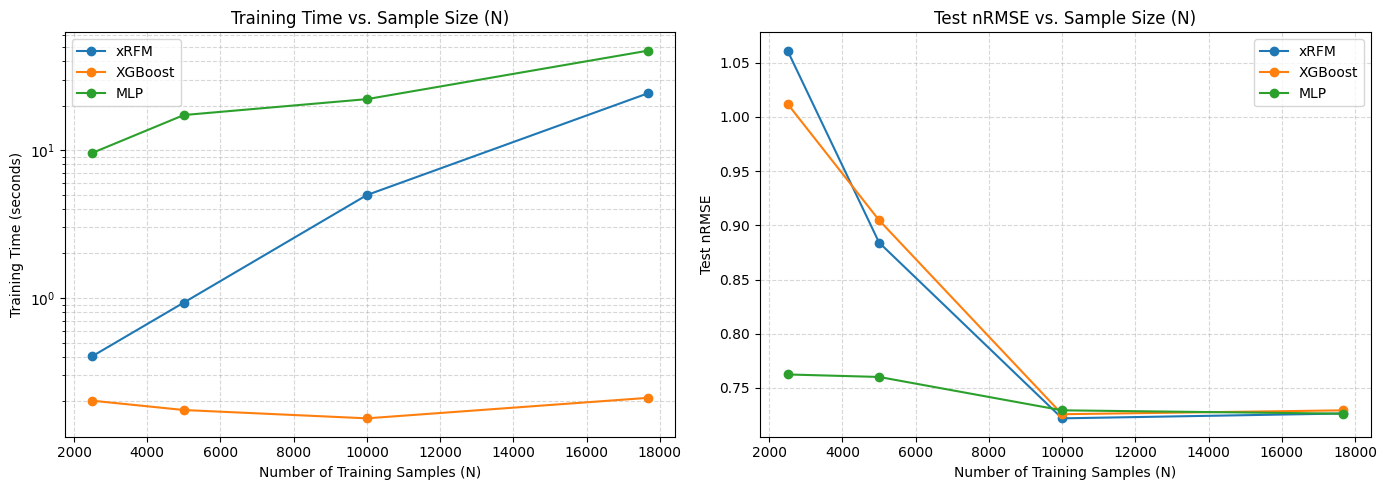

In [20]:
# Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for name in MODEL_SPECS:
    ax1.plot(sample_sizes, scale_results[name]["times"], marker="o", label=name)
ax1.set_title("Training Time vs. Sample Size (N)")
ax1.set_xlabel("Number of Training Samples (N)")
ax1.set_ylabel("Training Time (seconds)")
ax1.set_yscale("log")
ax1.legend()
ax1.grid(True, which="both", ls="--", alpha=0.5)

for name in MODEL_SPECS:
    ax2.plot(sample_sizes, scale_results[name]["nrmses"], marker="o", label=name)
ax2.set_title("Test nRMSE vs. Sample Size (N)")
ax2.set_xlabel("Number of Training Samples (N)")
ax2.set_ylabel("Test nRMSE")
ax2.legend()
ax2.grid(True, ls="--", alpha=0.5)

plt.tight_layout()
plt.show()